In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/')
from preprocessing import *
from metrics2 import *
from models import *
from utils import *
from balanced import *

In [2]:
from IPython.display import Markdown, display

dev_set = pd.read_csv('../data2/WAR_class_dev.csv')
test_set = pd.read_csv('../data2/WAR_class_test.csv')

def show_basic_info(dev_set, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {dev_set.shape}"))
    display(Markdown("**Primeras filas del dataset**:"))
    display(dev_set.head())
    display(Markdown("**Información del dataset**:"))
    display(dev_set.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(dev_set.describe())
    display(Markdown("**Distribución de clases**:"))
    display(dev_set['war_class'].value_counts(normalize=True))

show_basic_info(dev_set, "Datos Balanceados (Desarrollo)")


### Datos Balanceados (Desarrollo)

**Forma del dataset**: (6782, 6)

**Primeras filas del dataset**:

,poss,mp,raptor_total,war_total,pace_impact,war_class
0,2283.468774,826.890427,-3.369325,-0.006893,0.472195,2
1,1185.081598,567.265296,-5.389056,-0.615802,1.567405,2
2,5272.362761,2403.044668,7.084319,11.688727,-0.534305,3
3,7594.083790,3709.114977,5.532538,14.739138,-0.710111,3
4,8479.653469,3803.026613,5.089253,15.920002,-0.699135,3


**Información del dataset**:

...

None

**Estadísticas descriptivas**:

,poss,mp,raptor_total,war_total,pace_impact,war_class
count,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000,6782.000000
mean,3639.756160,1811.567736,-1.484226,2.772859,0.091128,2.031702
std,2097.793568,1039.122355,4.667840,5.239333,0.650618,0.793182
min,-414.390684,-235.333650,-43.449330,-6.589665,-6.935191,1.000000
25%,1913.845719,956.592966,-5.271681,-1.656335,-0.278206,1.000000
50%,3621.170163,1801.519616,-1.459043,0.490083,0.022291,2.000000
75%,5377.166126,2670.373141,2.201138,6.605975,0.389032,3.000000
max,9329.401575,4264.461247,32.904816,28.762877,11.193450,3.000000


**Distribución de clases**:

war_class
2    0.369950
3    0.330876
1    0.299174
Name: proportion, dtype: float64

 war_total = 'Wins Above Replacement — how many wins the player adds compared to a "replacement-level" player.
  this will be our target

 mp = minutes played

 poss = possesions in season

 raptor_offense: The player’s offensive Raptor rating — an advanced stat estimating offensive impact per 100 possessions.

 raptor_defense: Defensive Raptor rating — impact on defense per 100 possessions.

 raptor_total: Total Raptor rating — combines offense and defense for an overall impact metric.
 
 pace_impact = Impact on the team’s pace — how much the player influences the speed of the game

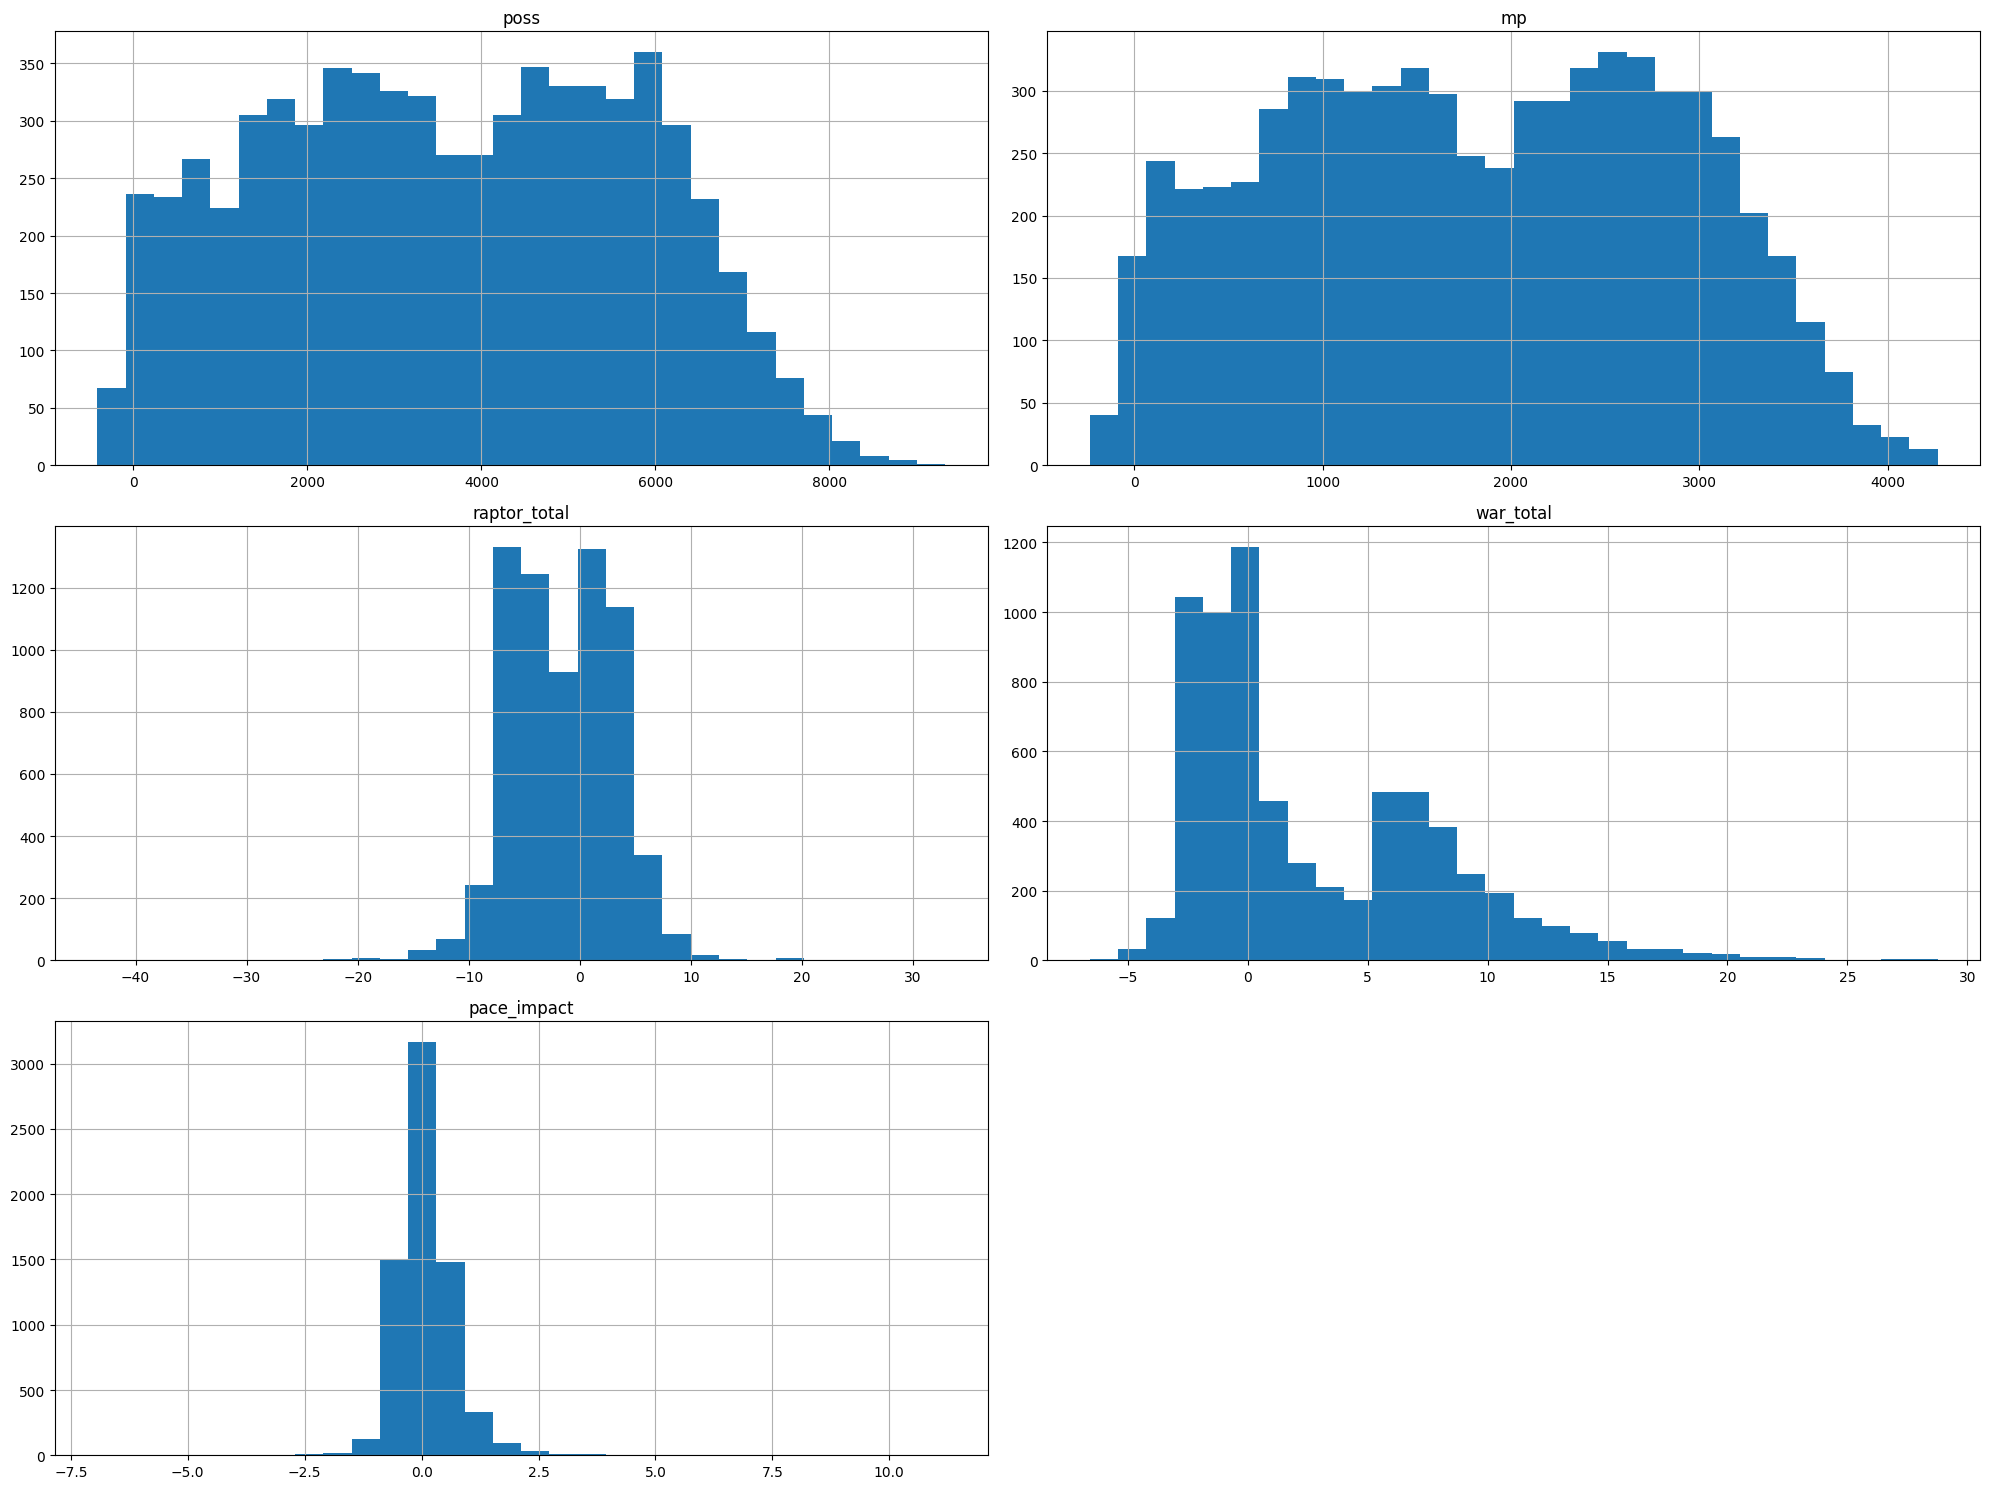

In [3]:
dev_set.drop(columns=["war_class"]).hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

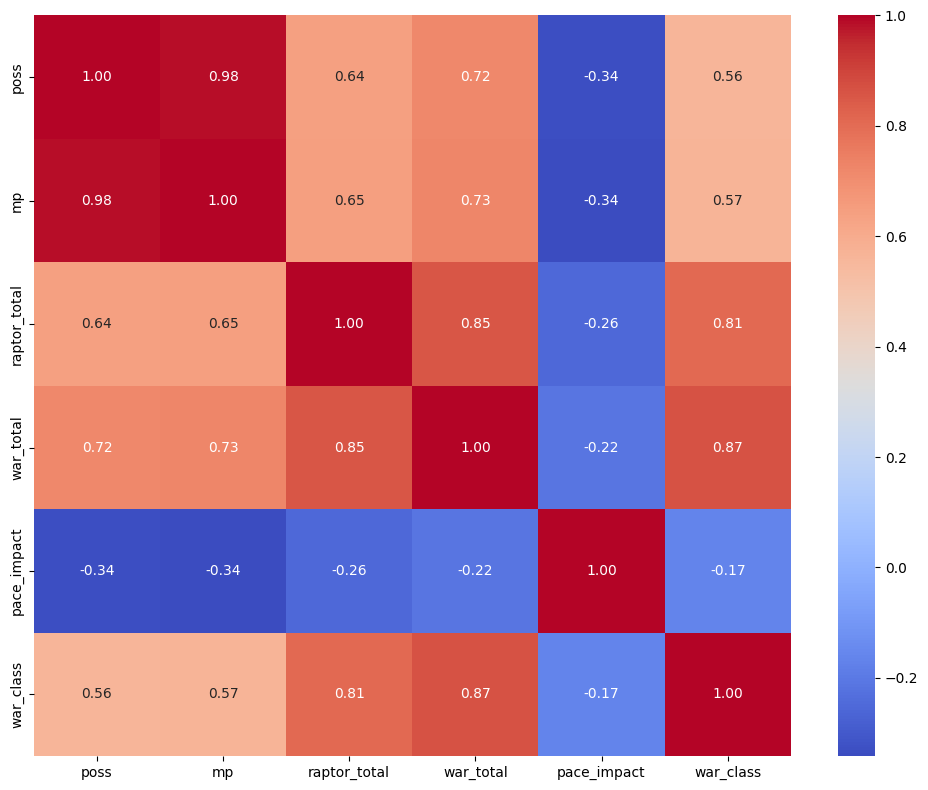

In [4]:
corr = dev_set.corr()

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
plt.tight_layout()
plt.show()

parecce ser que poss y mp estan altmente correlacionados

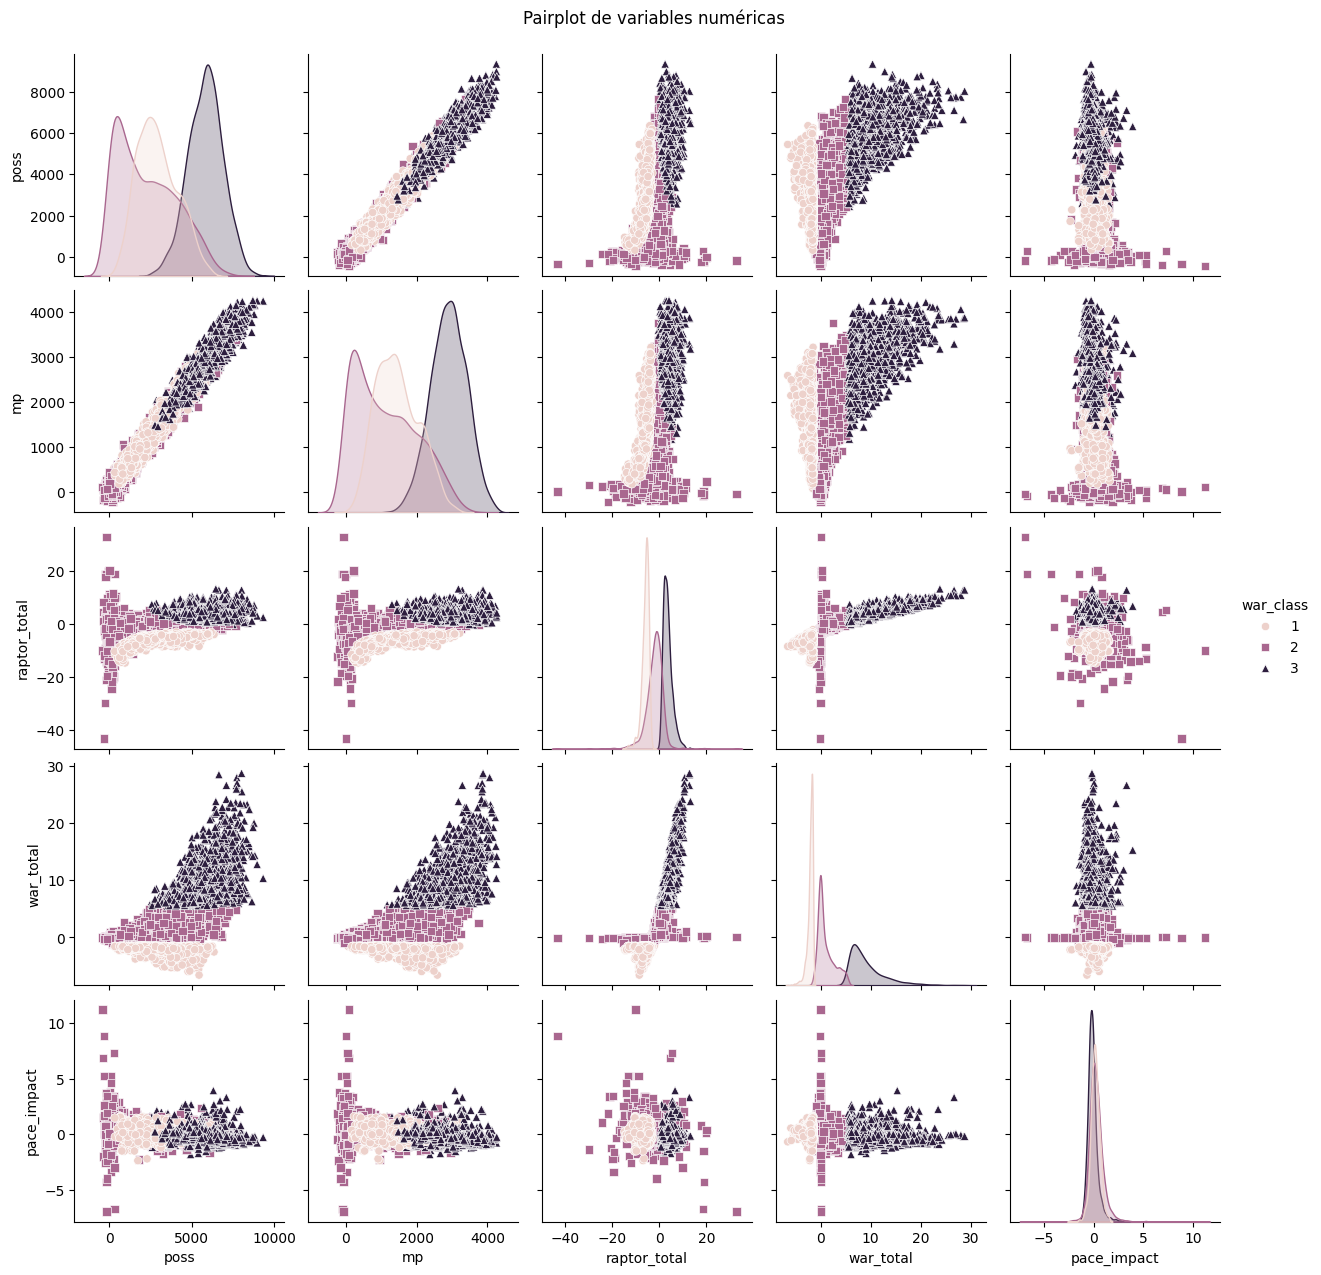

In [5]:
sns.pairplot(dev_set, hue="war_class", diag_kind="kde", markers=["o", "s", "^"],)
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

In [6]:
duplicados_dev = dev_set.duplicated().any()
print(f"¿Hay datos duplicados en dev_set? {duplicados_dev}")

¿Hay datos duplicados en dev_set? False


<Axes: xlabel='raptor_total', ylabel='war_total'>

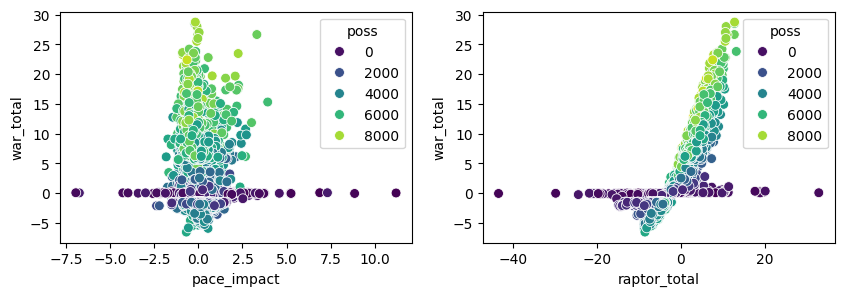

In [7]:
f,axs = plt.subplots(ncols=2, figsize = (10,3))
sns.scatterplot(x='pace_impact' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[0])
sns.scatterplot(x='raptor_total' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[1])

In [8]:
cut = 500
dev_set['significant_poss'] = (dev_set['poss'] >= cut).astype(int)
dev_set['significant_poss'] = dev_set['significant_poss'].astype('category')

In [9]:
X_train, X_val, y_train, y_val, means, stds = split_and_normalize(dev_set.drop(columns=['war_total']), 'war_class')


Resultados para Análisis Discriminante Lineal (LDA)

--- Reporte de Clasificación Multiclase  ---
              precision    recall  f1-score   support

           1       0.86      1.00      0.92       420
           2       1.00      0.72      0.84       497
           3       0.87      1.00      0.93       440

    accuracy                           0.90      1357
   macro avg       0.91      0.91      0.90      1357
weighted avg       0.91      0.90      0.89      1357


--- Matriz de Confusión  ---


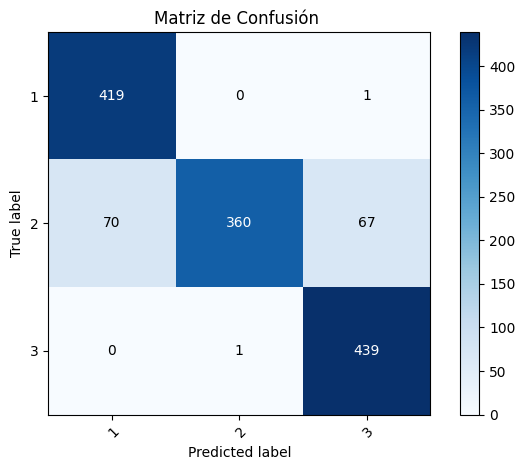


--- Curvas de Performance (One-vs-Rest)  ---
AUC ROC (OvR):
  - Clase '1': 0.984
  - Clase '2': 0.952
  - Clase '3': 0.996

AUC PR (OvR):
  - Clase '1': 0.925
  - Clase '2': 0.945
  - Clase '3': 0.991


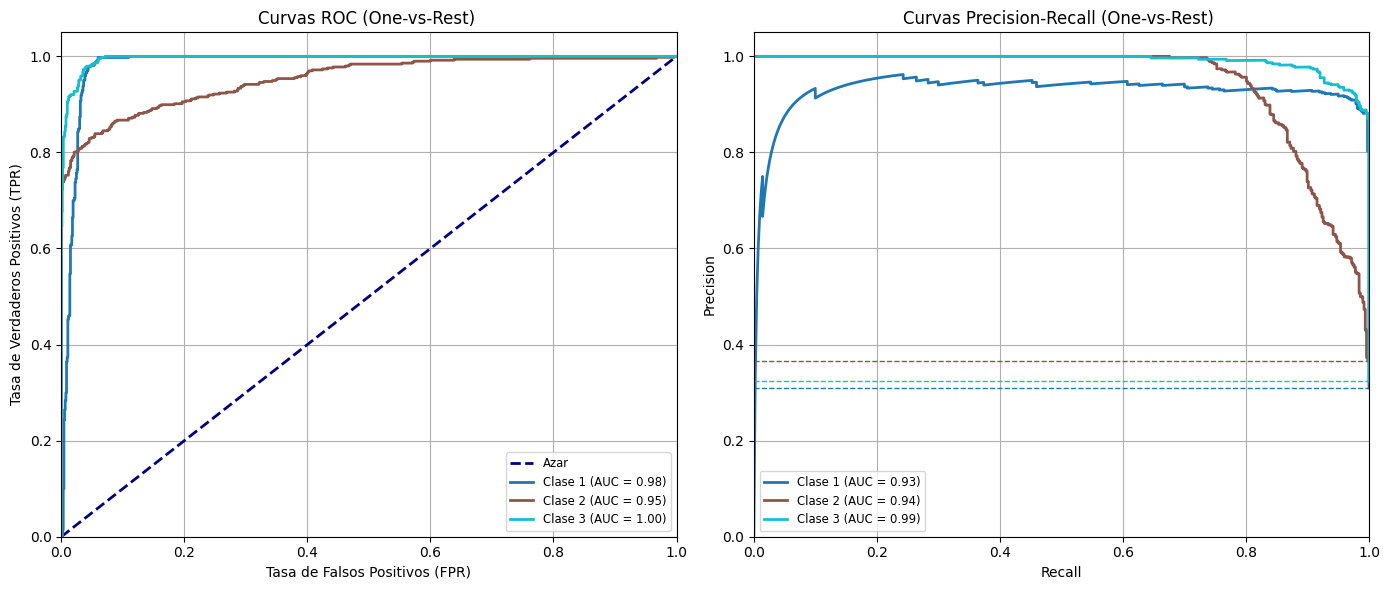

In [10]:
X_train_array = X_train.values
X_val_array = X_val.values
# Entrenar LDA
lda_model = LDA()
lda_model.fit(X_train_array, y_train)

# Evaluar
y_pred_lda = lda_model.predict(X_val_array)
y_proba_lda = lda_model.predict_proba(X_val_array)

# Mostrar métricas
print("\n" + "="*50)
print("Resultados para Análisis Discriminante Lineal (LDA)")
print("="*50)
metrics_lda = display_multiclass_metrics(y_val, y_pred_lda, y_proba_lda, lda_model.classes_)
print("\n" + "="*50)


Resultados para Regresión Logística Multiclase

--- Reporte de Clasificación Multiclase  ---
              precision    recall  f1-score   support

           1       0.84      0.96      0.90       420
           2       0.95      0.74      0.83       497
           3       0.90      0.99      0.94       440

    accuracy                           0.89      1357
   macro avg       0.89      0.90      0.89      1357
weighted avg       0.90      0.89      0.89      1357


--- Matriz de Confusión  ---


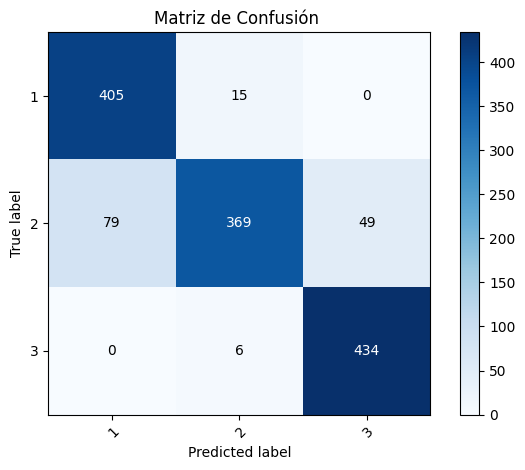


--- Curvas de Performance (One-vs-Rest)  ---
AUC ROC (OvR):
  - Clase '1': 0.968
  - Clase '2': 0.917
  - Clase '3': 0.997

AUC PR (OvR):
  - Clase '1': 0.850
  - Clase '2': 0.909
  - Clase '3': 0.993


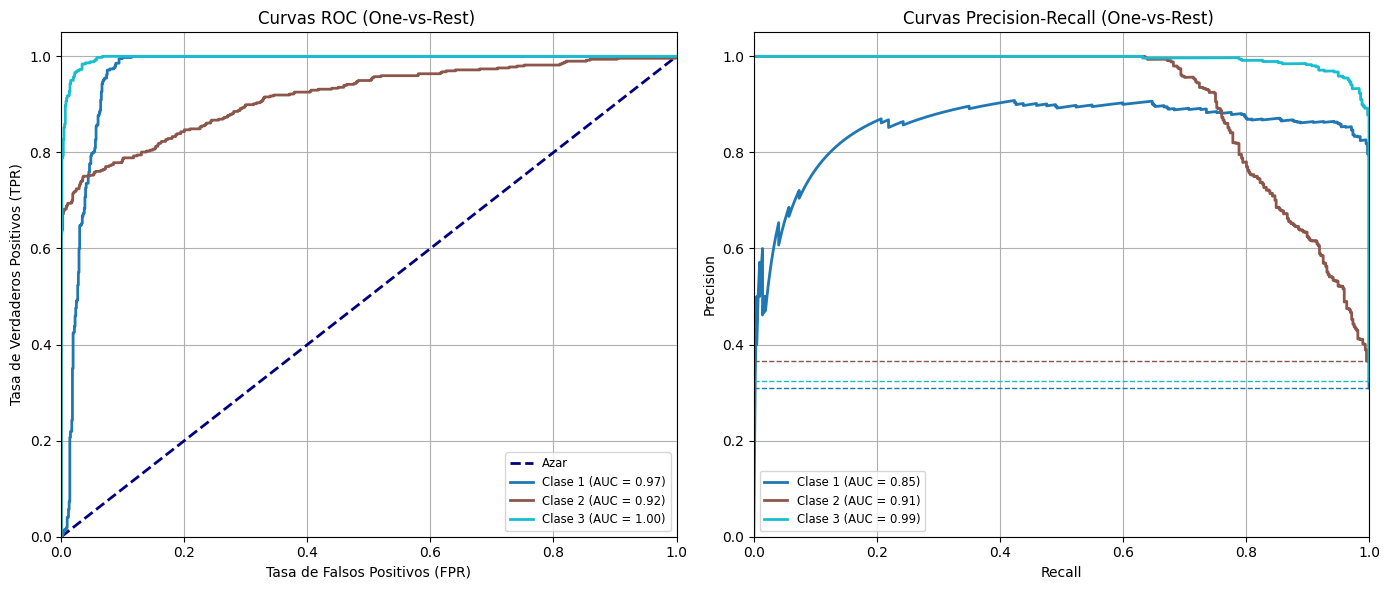

Multinomial Logistic Regression Coefficients:
Class 1:
  Feature 0: 0.2286
  Feature 1: 0.2947
  Feature 2: -2.9727
  Feature 3: -0.2096
  Feature 4: 0.1947
Class 2:
  Feature 0: -0.9082
  Feature 1: -1.1274
  Feature 2: 0.4262
  Feature 3: -0.0086
  Feature 4: 1.0618
Class 3:
  Feature 0: 0.6795
  Feature 1: 0.8327
  Feature 2: 2.5464
  Feature 3: 0.2182
  Feature 4: -1.2565



In [11]:
# Entrenar Regresión Logística Multiclase con regularización
mlr_model = MultinomialLogisticRegression(
    learning_rate=0.1,
    n_iter=1000,
    lambda_=0.1  # Parámetro de regularización
)
mlr_model.fit(X_train_array, y_train)

# Evaluar
y_pred_mlr = mlr_model.predict(X_val_array)
y_proba_mlr = mlr_model.predict_proba(X_val_array)

# Mostrar métricas
print("\n" + "="*50)
print("Resultados para Regresión Logística Multiclase")
print("="*50)
metrics_mlr = display_multiclass_metrics(y_val, y_pred_mlr, y_proba_mlr, mlr_model.classes_)

# Mostrar coeficientes para interpretabilidad
mlr_model.print_coefficients()

In [ ]:
from itertools import product # Para generar combinaciones

param_grid = {
    'n_estimators': [50, 100, 150],          # Número de árboles
    'max_depth': [5, 10, None],             # Profundidad máxima (None = sin límite)
    'min_samples_split': [2, 5, 10],        # Mínimo de muestras para dividir un nodo
    'max_features': [1, 0.7, None],    # Número de features a considerar (None = todas)
}

config_keys = param_grid.keys()
configs = [dict(zip(config_keys, values)) for values in product(*param_grid.values())]

n_folds = 5 # Número de folds para la validación cruzada
random_seed = 42 # Para reproducibilidad

best_avg_score = -1 # Usamos -1 porque 0 podría ser un score válido
best_params = None
results = [] # Para guardar los resultados de cada configuración

print(f"Iniciando búsqueda de hiperparámetros con {n_folds}-Fold Cross-Validation...")
print(f"Total de configuraciones a probar: {len(configs)}")

# --- Bucle de Validación Cruzada ---
# Crear los folds UNA VEZ fuera del bucle de configuraciones
cv_folds = create_stratified_k_folds(X_train_array, y_train, k=n_folds, random_state=random_seed)

for i, params in enumerate(configs):
    print(f"\n[{i+1}/{len(configs)}] Probando configuración: {params}")
    fold_scores = [] # Scores para la configuración actual en cada fold

    for fold, (train_idx, val_idx) in enumerate(cv_folds):
        # Obtener datos para este fold específico
        X_train_fold, y_train_fold = X_train_array[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train_array[val_idx], y_train[val_idx]

        # Entrenar el modelo en el fold de entrenamiento
        rf_model = RandomForest(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            max_features=params.get('max_features'),
            random_state=random_seed # Semilla para el RF mismo
        )
        rf_model.fit(X_train_fold, y_train_fold)

        # Evaluar en el fold de validación
        y_pred_fold = rf_model.predict(X_val_fold)

        # Elegir la métrica para optimizar (Weighted F1 suele ser buena para multiclase)
        # score = accuracy_score(y_val_fold, y_pred_fold)
        score = f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
        fold_scores.append(score)

    # Calcular el score promedio para esta configuración
    avg_score = np.mean(fold_scores)
    results.append({'params': params, 'avg_score': avg_score, 'fold_scores': fold_scores})
    print(f"  Score promedio en {n_folds} folds (Weighted F1): {avg_score:.4f}")

    # Actualizar si encontramos una mejor configuración
    if avg_score > best_avg_score:
        best_avg_score = avg_score
        best_params = params
        print(f"  ¡Nueva mejor configuración encontrada!")

# --- Entrenamiento y Evaluación Final ---
print("\n" + "="*60)
print("Búsqueda de hiperparámetros con Cross-Validation completada.")
print(f"Mejor configuración encontrada: {best_params}")
print(f"Mejor score promedio (Weighted F1) en CV: {best_avg_score:.4f}")
print("="*60)

# Entrenar el modelo final con los mejores parámetros en TODO el set de entrenamiento
print("\nEntrenando el modelo final con la mejor configuración...")
final_rf_model = RandomForest(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params.get('min_samples_leaf', 1),
    max_features=best_params.get('max_features'),
    criterion=best_params['criterion'],
    random_state=random_seed
)
# Entrenar en el conjunto completo de entrenamiento original
final_rf_model.fit(X_train_array, y_train)

# Evaluar el modelo final en el conjunto de validación HELD-OUT (el que no se usó en CV)
print("\nEvaluando el modelo final en el set de validación HELD-OUT...")
y_pred_final = final_rf_model.predict(X_val_array)
y_proba_final = final_rf_model.predict_proba(X_val_array) # Necesario para display_multiclass_metrics

# Usar la función de display que incluye reporte, CM y curvas ROC/PR (OvR)
# Asegúrate que las clases se pasen correctamente si es necesario
# Si tu modelo RF guarda las clases en .classes_ como en el ejemplo, puedes usarlo.
# Si no, obtén las clases de y_val o y_train.
class_labels_final = sorted(np.unique(y_val)) # O usa final_rf_model.classes_ si existe
class_names_final = [str(c) for c in class_labels_final] # Nombres simples

display_multiclass_metrics(
    y_val,
    y_pred_final,
    y_proba=y_proba_final,
    labels=class_labels_final,
    target_names=class_names_final,
    title_suffix="Modelo Final (Optimizado con CV)"
)

Iniciando búsqueda de hiperparámetros con 5-Fold Cross-Validation...
Total de configuraciones a probar: 81

[1/81] Probando configuración: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2, 'max_features': 1}
  Score promedio en 5 folds (Weighted F1): 0.7241
  ¡Nueva mejor configuración encontrada!

[2/81] Probando configuración: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2, 'max_features': 0.7}
  Score promedio en 5 folds (Weighted F1): 0.9393
  ¡Nueva mejor configuración encontrada!

[3/81] Probando configuración: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2, 'max_features': None}
  Score promedio en 5 folds (Weighted F1): 0.8227

[4/81] Probando configuración: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5, 'max_features': 1}
  Score promedio en 5 folds (Weighted F1): 0.7241

[5/81] Probando configuración: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5, 'max_features': 0.7}
  Score promedio en 5 folds (Weighted F1): 0

In [ ]:
# # 1. Verificar las clases
# print("Clases en los datos:", np.unique(y_train))

# # 2. Entrenamiento del Random Forest
# rf_model = RandomForest(
#     n_estimators=10
#     max_depth=10,
#     min_samples_split=2,
#     criterion='entropy',
#     random_state=42
# )
# rf_model.fit(X_train_array, y_train)

# # 3. Evaluación
# y_pred_rf = rf_model.predict(X_val_array)
# y_proba_rf = rf_model.predict_proba(X_val_array)

# # 4. Verificar resultados
# print("Shape de y_proba_rf:", y_proba_rf.shape)
# print("Clases predichas:", np.unique(y_pred_rf))

# # 5. Mostrar métricas
# print("\n" + "="*50)
# print("Resultados para Random Forest con clases 1, 2, 3")
# print("="*50)
# display_multiclass_metrics(y_val, y_pred_rf, y_proba_rf, rf_model.classes_)
# # Mostrar importancia de características


In [ ]:
# Crear tabla comparativa
comparison_df = pd.DataFrame([metrics_lda, metrics_mlr, metrics_rf])
comparison_df.set_index('Modelo', inplace=True)

# Mostrar tabla
print("\n" + "="*50)
print("Comparación de Modelos")
print("="*50)
display(comparison_df) # Display the DataFrame directly

# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC-ROC', 'AUC-PR']

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    comparison_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'salmon', 'lightgreen'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Si tenemos características 2D o podemos reducir la dimensionalidad (PCA manual)
# Podemos visualizar las fronteras de decisión

# Ejemplo con las dos características más importantes del Random Forest
if len(feature_names) >= 2:
    # Seleccionar las dos características más importantes
    importances = best_rf.feature_importances_
    top_two_idx = np.argsort(importances)[-2:]
    X_train_2d = X_train_array[:, top_two_idx]
    X_val_2d = X_val_array[:, top_two_idx]
    
    # Entrenar modelos en el subespacio 2D para visualización
    print("\nVisualización de fronteras de decisión en espacio 2D")
    
    # LDA en 2D
    lda_2d = LDA()
    lda_2d.fit(X_train_2d, y_train)
    plot_decision_boundary(lda_2d, X_val_2d, y_val, title="Frontera de Decisión - LDA")
    
    # Regresión Logística en 2D
    mlr_2d = MultinomialLogisticRegression(learning_rate=0.1, n_iter=1000)
    mlr_2d.fit(X_train_2d, y_train)
    plot_decision_boundary(mlr_2d, X_val_2d, y_val, title="Frontera de Decisión - Regresión Logística")
    
    # Random Forest en 2D
    rf_2d = RandomForest(n_estimators=50, max_depth=5, criterion='entropy')
    rf_2d.fit(X_train_2d, y_train)
    plot_decision_boundary(rf_2d, X_val_2d, y_val, title="Frontera de Decisión - Random Forest")

In [ ]:
# Identificar el mejor modelo basado en F1-Score (balance entre precision y recall)
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = best_model_idx
best_model_metrics = comparison_df.loc[best_model_idx]

print("\n" + "="*50)
print("Mejor Modelo Seleccionado")
print("="*50)
print(f"Modelo: {best_model_name}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"AUC-ROC: {best_model_metrics['AUC-ROC']:.4f}")
print(f"AUC-PR: {best_model_metrics['AUC-PR']:.4f}")

# Guardar el mejor modelo
if best_model_name == 'LDA':
    best_model = lda_model
elif best_model_name == 'Regresión Logística':
    best_model = mlr_model
else:
    best_model = best_rf

# Si queremos guardar el modelo para producción
# from utils import save_model
# save_model(best_model, 'mejor_modelo.pkl')